# CrabsAlpes: comparación reproducible de modelos de regresión

Este notebook compara modelos supervisados para estimar la edad (`Age`, en meses) de un cangrejo a partir de sus características físicas. Es un problema de **regresión** porque el error conserva significado cuantitativo: equivocarse por un mes es menos grave que equivocarse por diez.

La selección se realiza exclusivamente con el conjunto de desarrollo mediante validación cruzada. El 20 % de prueba queda aislado hasta elegir el modelo ganador. La métrica principal es MAE, expresada directamente en meses; RMSE, $R^2$, estabilidad y tiempo complementan la decisión.

## 0. Instalación opcional

Ejecute la siguiente celda solo si el entorno no tiene las dependencias. Después, reinicie el kernel.

In [1]:
 %pip install -q numpy pandas scipy scikit-learn matplotlib seaborn joblib catboost xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import platform, time, warnings
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

SEED = 42
N_SPLITS = 5
N_ITER = 15
N_JOBS = -1
np.random.seed(SEED)
warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')

## 1. Carga, contrato de datos y auditoría

In [3]:
DATA_PATH = Path('CrabAgePrediction.csv')
TARGET = 'Age'
RAW_FEATURES = ['Sex', 'Length', 'Diameter', 'Height', 'Weight',
                'Shucked Weight', 'Viscera Weight', 'Shell Weight']
EXPECTED_COLUMNS = RAW_FEATURES + [TARGET]

crabs_raw = pd.read_csv(DATA_PATH)
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(crabs_raw.columns))
extra_columns = sorted(set(crabs_raw.columns) - set(EXPECTED_COLUMNS))
assert not missing_columns, f'Faltan columnas requeridas: {missing_columns}'
assert not extra_columns, f'Hay columnas inesperadas: {extra_columns}'
assert pd.api.types.is_numeric_dtype(crabs_raw[TARGET]), 'Age debe ser numérica'
print(f'Dimensiones: {crabs_raw.shape[0]:,} filas × {crabs_raw.shape[1]} columnas')
display(crabs_raw.head())
display(crabs_raw.dtypes.rename('tipo').to_frame())

Dimensiones: 3,906 filas × 9 columnas


,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age
0,F,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,9
1,M,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,6
2,I,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,6
3,F,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,10
4,I,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,6


,tipo
Sex,object
Length,float64
Diameter,float64
Height,float64
Weight,float64
Shucked Weight,float64
Viscera Weight,float64
Shell Weight,float64
Age,int64


In [4]:
audit = pd.DataFrame({
    'tipo': crabs_raw.dtypes.astype(str),
    'faltantes': crabs_raw.isna().sum(),
    'faltantes_%': crabs_raw.isna().mean().mul(100).round(2),
    'unicos': crabs_raw.nunique(dropna=True),
})
display(audit)
display(crabs_raw.describe(include='all').T)
print('Duplicados exactos:', int(crabs_raw.duplicated().sum()))
print('Valores de Sex:', crabs_raw['Sex'].value_counts(dropna=False).to_dict())
print('Edades extremas conservadas:', int((crabs_raw[TARGET] >= 18).sum()))
print('Alturas iguales a cero (sospechosas, no eliminadas):', int(crabs_raw['Height'].eq(0).sum()))

,tipo,faltantes,faltantes_%,unicos
Sex,object,5,0.13,3
Length,float64,5,0.13,134
Diameter,float64,9,0.23,111
Height,float64,9,0.23,51
Weight,float64,26,0.67,2332
Shucked Weight,float64,6,0.15,1479
Viscera Weight,float64,10,0.26,867
Shell Weight,float64,5,0.13,906
Age,int64,0,0.00,29


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sex,3901,3,M,1442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Length,3901.0,NaN,NaN,NaN,1.311779,0.300601,0.1875,1.125,1.3625,1.5375,2.0375
Diameter,3897.0,NaN,NaN,NaN,1.020936,0.248254,0.1375,0.875,1.0625,1.2,1.625
Height,3897.0,NaN,NaN,NaN,0.349583,0.105155,0.0,0.2875,0.3625,0.4125,2.825
Weight,3880.0,NaN,NaN,NaN,23.593561,13.908396,0.056699,12.686401,22.807173,32.825177,80.101512
Shucked Weight,3900.0,NaN,NaN,NaN,10.211036,6.288522,0.028349,5.340337,9.546694,14.259799,42.184056
Viscera Weight,3896.0,NaN,NaN,NaN,5.139886,3.106692,0.014175,2.675484,4.861939,7.200773,21.54562
Shell Weight,3901.0,NaN,NaN,NaN,6.801725,3.945943,0.042524,3.727959,6.662133,9.355335,28.491248
Age,3906.0,NaN,NaN,NaN,9.967998,3.285673,1.0,8.0,10.0,11.0,50.0


Duplicados exactos: 6
Valores de Sex: {'M': 1442, 'I': 1237, 'F': 1222, nan: 5}
Edades extremas conservadas: 128
Alturas iguales a cero (sospechosas, no eliminadas): 2


In [5]:
predictor_duplicates = crabs_raw.duplicated(subset=RAW_FEATURES, keep=False)
conflicts = (crabs_raw.loc[predictor_duplicates]
             .groupby(RAW_FEATURES, dropna=False)[TARGET]
             .agg(n='size', edades_distintas='nunique', edad_min='min', edad_max='max')
             .query('edades_distintas > 1')
             .reset_index())
print('Grupos con predictores iguales y edades diferentes:', len(conflicts))
display(conflicts.head(10))

crabs = crabs_raw.drop_duplicates().reset_index(drop=True)
print(f'Se eliminaron {len(crabs_raw) - len(crabs)} duplicados exactos; quedan {len(crabs):,} registros.')

Grupos con predictores iguales y edades diferentes: 5


,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,n,edades_distintas,edad_min,edad_max
0,F,1.8000,1.3750,0.4875,58.768513,30.376489,12.091062,14.217274,2,2,8,9
1,I,0.6875,0.5125,0.1625,2.863300,1.162330,0.595340,0.963883,3,3,5,10
2,I,1.5875,1.2625,0.4750,37.747359,16.456885,7.144074,12.332033,3,2,17,20
3,M,1.2750,1.0000,0.3500,18.469699,6.959802,4.720192,5.244657,2,2,10,50
4,M,1.6375,1.2750,0.5375,50.561333,25.188531,11.609120,11.892615,3,3,9,11


Se eliminaron 6 duplicados exactos; quedan 3,900 registros.


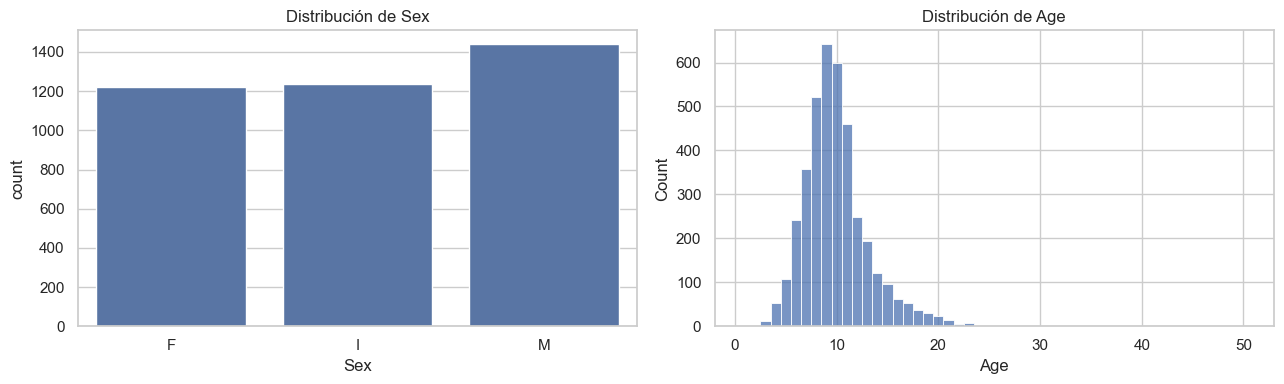

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=crabs, x='Sex', ax=axes[0], order=['F', 'I', 'M'])
axes[0].set_title('Distribución de Sex')
sns.histplot(data=crabs, x=TARGET, discrete=True, ax=axes[1])
axes[1].set_title('Distribución de Age')
plt.tight_layout()
plt.show()

## 2. Ingeniería de características y partición

Las proporciones siguientes son transformaciones deterministas por fila: no aprenden estadísticas globales y, por tanto, pueden calcularse antes de la partición. Toda división por cero se transforma en valor faltante para que el imputador la trate dentro de cada pliegue.

In [7]:
def add_physical_features(frame):
    result = frame.copy()
    safe = lambda numerator, denominator: numerator.div(denominator.replace(0, np.nan))
    result['Diameter / Length'] = safe(result['Diameter'], result['Length'])
    result['Height / Length'] = safe(result['Height'], result['Length'])
    result['Shell / Weight'] = safe(result['Shell Weight'], result['Weight'])
    result['Shucked / Weight'] = safe(result['Shucked Weight'], result['Weight'])
    result['Viscera / Weight'] = safe(result['Viscera Weight'], result['Weight'])
    volume = result['Length'] * result['Diameter'] * result['Height']
    result['Approx Density'] = safe(result['Weight'], volume)
    return result.replace([np.inf, -np.inf], np.nan)

X = add_physical_features(crabs[RAW_FEATURES])
y = crabs[TARGET].copy()
NUMERIC_FEATURES = [column for column in X.columns if column != 'Sex']
CATEGORICAL_FEATURES = ['Sex']
assert not np.isinf(X[NUMERIC_FEATURES].to_numpy()).any()
display(X.head())

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Diameter / Length,Height / Length,Shell / Weight,Shucked / Weight,Viscera / Weight,Approx Density
0,F,1.4375,1.1750,0.4125,24.635715,12.332033,5.584852,6.747181,0.817391,0.286957,0.273878,0.500575,0.226697,35.358636
1,M,0.8875,0.6500,0.2125,5.400580,2.296310,1.374951,1.559222,0.732394,0.239437,0.288714,0.425197,0.254593,44.055459
2,I,1.0375,0.7750,0.2500,7.952035,3.231843,1.601747,2.764076,0.746988,0.240964,0.347594,0.406417,0.201426,39.559287
3,F,1.1750,0.8875,0.2500,13.480187,4.748541,2.282135,5.244657,0.755319,0.212766,0.389064,0.352261,0.169295,51.707041
4,I,0.8875,0.6625,0.2125,6.903103,3.458639,1.488349,1.700970,0.746479,0.239437,0.246407,0.501027,0.215606,55.249861


In [8]:
# Los cuantiles permiten conservar una distribución de edades similar sin tratar cada edad escasa como estrato.
age_strata = pd.qcut(y.rank(method='first'), q=10, labels=False)
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=age_strata
)
print('Desarrollo:', X_dev.shape, '| Prueba aislada:', X_test.shape)
print('Age desarrollo:', y_dev.describe()[['min', 'mean', 'max']].round(2).to_dict())
print('Age prueba:', y_test.describe()[['min', 'mean', 'max']].round(2).to_dict())

Desarrollo: (3120, 14) | Prueba aislada: (780, 14)
Age desarrollo: {'min': 1.0, 'mean': 9.97, 'max': 50.0}
Age prueba: {'min': 4.0, 'mean': 9.95, 'max': 24.0}


In [9]:
numeric_scaled = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
numeric_unscaled = Pipeline([('imputer', SimpleImputer(strategy='median'))])
categorical = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

linear_preprocessor = ColumnTransformer([
    ('num', numeric_scaled, NUMERIC_FEATURES),
    ('cat', categorical, CATEGORICAL_FEATURES),
])
tree_preprocessor = ColumnTransformer([
    ('num', numeric_unscaled, NUMERIC_FEATURES),
    ('cat', categorical, CATEGORICAL_FEATURES),
])
def make_pipeline(model, scaled=False):
    return Pipeline([('preprocess', linear_preprocessor if scaled else tree_preprocessor), ('model', model)])

## 3. Comparación inicial con los mismos cinco pliegues

In [10]:
models = {
    'Dummy mediana': make_pipeline(DummyRegressor(strategy='median')),
    'Regresión lineal': make_pipeline(LinearRegression(), scaled=True),
    'Ridge': make_pipeline(Ridge(alpha=1.0), scaled=True),
    'Elastic Net': make_pipeline(ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000), scaled=True),
    'Huber': make_pipeline(HuberRegressor(max_iter=1000), scaled=True),
    'Random Forest': make_pipeline(RandomForestRegressor(n_estimators=250, min_samples_leaf=2, random_state=SEED, n_jobs=1)),
    'Extra Trees': make_pipeline(ExtraTreesRegressor(n_estimators=250, min_samples_leaf=2, random_state=SEED, n_jobs=1)),
    'HistGradientBoosting': make_pipeline(HistGradientBoostingRegressor(max_iter=250, random_state=SEED)),
    'CatBoost': make_pipeline(CatBoostRegressor(iterations=350, depth=6, learning_rate=0.05, loss_function='MAE', verbose=False, random_seed=SEED, thread_count=1)),
    'XGBoost': make_pipeline(XGBRegressor(n_estimators=350, max_depth=5, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, objective='reg:squarederror', random_state=SEED, n_jobs=1)),
    'LightGBM': make_pipeline(LGBMRegressor(n_estimators=350, learning_rate=0.05, num_leaves=31, random_state=SEED, n_jobs=1, verbosity=-1)),
}
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}
len(models)

11

In [11]:
benchmark_rows = []
benchmark_start = time.perf_counter()
for name, estimator in models.items():
    started = time.perf_counter()
    scores = cross_validate(estimator, X_dev, y_dev, cv=cv, scoring=scoring,
                            return_train_score=True, n_jobs=N_JOBS, error_score='raise')
    benchmark_rows.append({
        'Modelo': name,
        'MAE_CV': -scores['test_mae'].mean(),
        'MAE_std': (-scores['test_mae']).std(ddof=1),
        'RMSE_CV': -scores['test_rmse'].mean(),
        'RMSE_std': (-scores['test_rmse']).std(ddof=1),
        'R2_CV': scores['test_r2'].mean(),
        'MAE_train': -scores['train_mae'].mean(),
        'Brecha_MAE': (-scores['test_mae'].mean()) - (-scores['train_mae'].mean()),
        'Tiempo_s': time.perf_counter() - started,
    })
    print(f'{name:22s} MAE={benchmark_rows[-1]["MAE_CV"]:.3f} ± {benchmark_rows[-1]["MAE_std"]:.3f}')
benchmark = pd.DataFrame(benchmark_rows).sort_values(['MAE_CV', 'MAE_std']).reset_index(drop=True)
print(f'Tiempo total del benchmark: {time.perf_counter() - benchmark_start:.1f} s')
display(benchmark.style.format({c: '{:.3f}' for c in benchmark.columns if c != 'Modelo'}))

Dummy mediana          MAE=2.396 ± 0.117
Regresión lineal       MAE=1.635 ± 0.044
Ridge                  MAE=1.635 ± 0.044
Elastic Net            MAE=1.632 ± 0.048
Huber                  MAE=1.592 ± 0.059
Random Forest          MAE=1.549 ± 0.022
Extra Trees            MAE=1.540 ± 0.025
HistGradientBoosting   MAE=1.626 ± 0.052
CatBoost               MAE=1.487 ± 0.035
XGBoost                MAE=1.567 ± 0.035
LightGBM               MAE=1.608 ± 0.049
Tiempo total del benchmark: 34.4 s


,Modelo,MAE_CV,MAE_std,RMSE_CV,RMSE_std,R2_CV,MAE_train,Brecha_MAE,Tiempo_s
0,CatBoost,1.487,0.035,2.233,0.164,0.545,1.148,0.339,4.881
1,Extra Trees,1.540,0.025,2.258,0.141,0.533,0.387,1.153,3.823
2,Random Forest,1.549,0.022,2.256,0.135,0.534,0.672,0.877,9.044
3,XGBoost,1.567,0.035,2.284,0.116,0.522,0.729,0.838,1.939
4,Huber,1.592,0.059,2.423,0.205,0.464,1.572,0.021,0.354
5,LightGBM,1.608,0.049,2.337,0.101,0.499,0.626,0.983,1.175
6,HistGradientBoosting,1.626,0.052,2.365,0.107,0.488,0.474,1.152,1.692
7,Elastic Net,1.632,0.048,2.386,0.199,0.481,1.614,0.019,0.177
8,Ridge,1.635,0.044,2.388,0.190,0.480,1.614,0.021,0.201
9,Regresión lineal,1.635,0.044,2.391,0.188,0.479,1.614,0.022,4.277


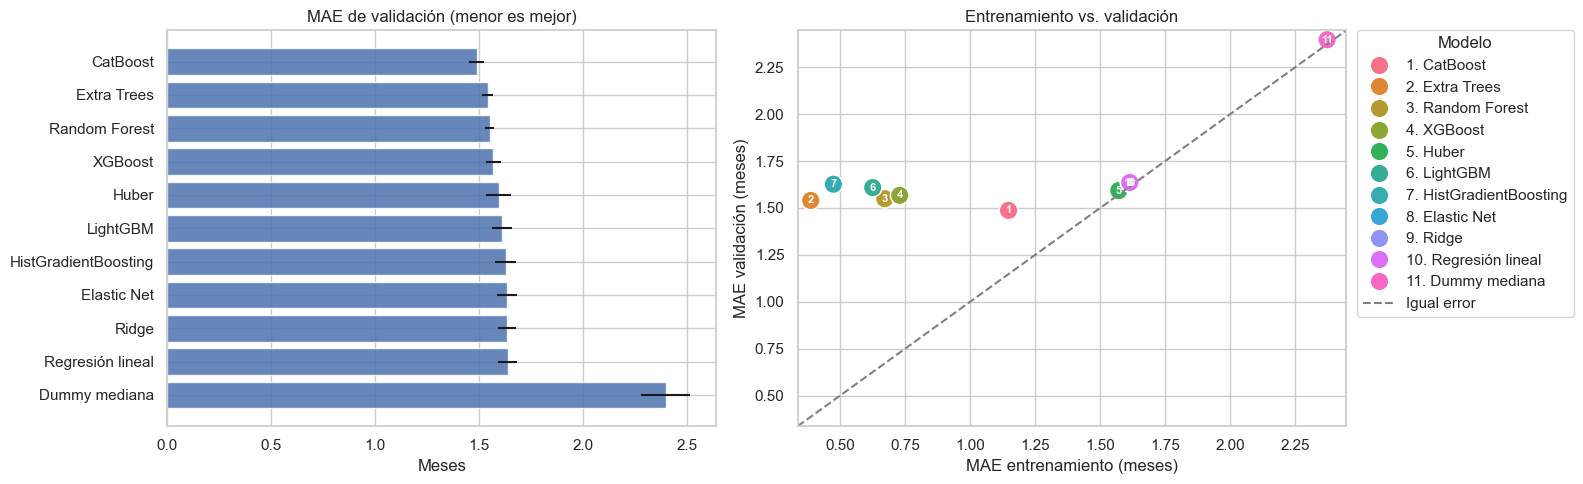

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ordered = benchmark.sort_values('MAE_CV', ascending=False)

axes[0].barh(
    ordered['Modelo'],
    ordered['MAE_CV'],
    xerr=ordered['MAE_std'],
    alpha=.85
)
axes[0].set_title('MAE de validación (menor es mejor)')
axes[0].set_xlabel('Meses')

# Asignar un número a cada modelo
plot_data = benchmark.reset_index(drop=True).copy()
plot_data['Numero'] = np.arange(1, len(plot_data) + 1)
plot_data['Modelo_leyenda'] = (
    plot_data['Numero'].astype(str) + '. ' + plot_data['Modelo']
)

sns.scatterplot(
    data=plot_data,
    x='MAE_train',
    y='MAE_CV',
    hue='Modelo_leyenda',
    s=180,
    ax=axes[1],
    legend='full'
)

# Escribir el número en el centro de cada punto
for _, row in plot_data.iterrows():
    axes[1].annotate(
        str(row['Numero']),
        (row['MAE_train'], row['MAE_CV']),
        ha='center',
        va='center',
        color='white',
        fontsize=8,
        fontweight='bold'
    )

lims = [
    benchmark[['MAE_train', 'MAE_CV']].min().min() - .05,
    benchmark[['MAE_train', 'MAE_CV']].max().max() + .05
]

axes[1].plot(
    lims,
    lims,
    '--',
    color='gray',
    label='Igual error'
)

axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_title('Entrenamiento vs. validación')
axes[1].set_xlabel('MAE entrenamiento (meses)')
axes[1].set_ylabel('MAE validación (meses)')

axes[1].legend(
    title='Modelo',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

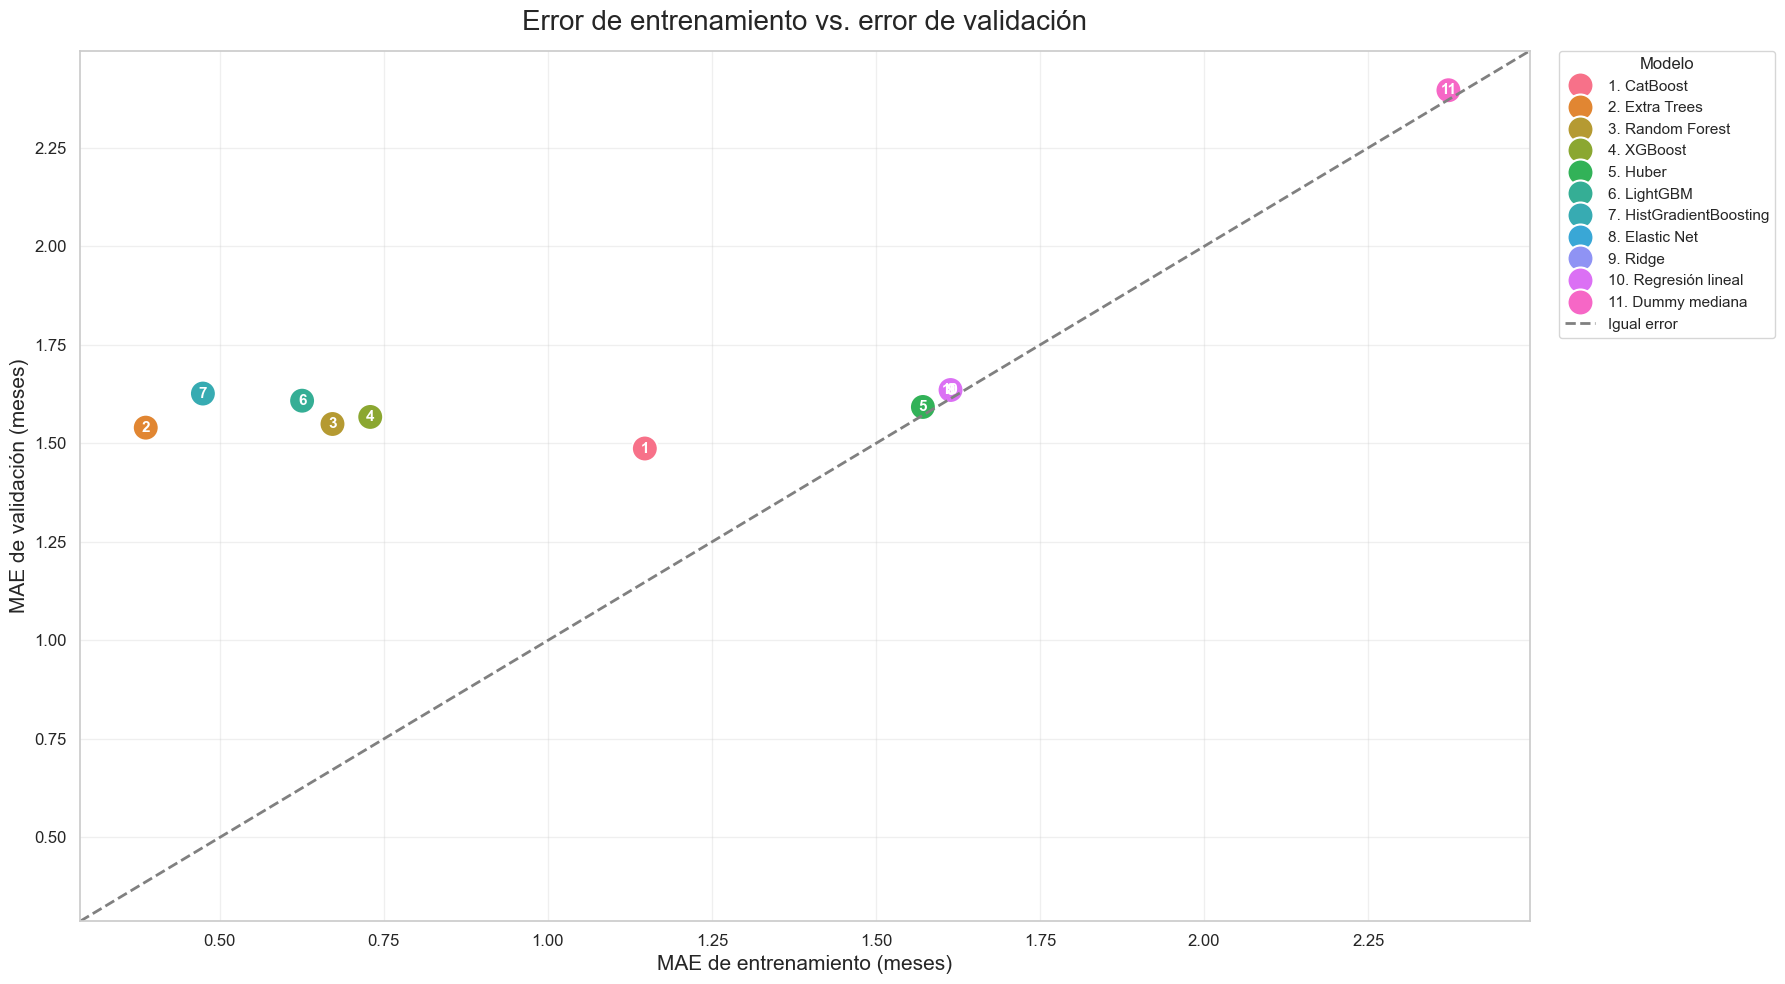

In [13]:
fig, ax = plt.subplots(figsize=(18, 10))

# Asignar un número a cada modelo
plot_data = benchmark.reset_index(drop=True).copy()
plot_data['Numero'] = np.arange(1, len(plot_data) + 1)
plot_data['Modelo_leyenda'] = (
    plot_data['Numero'].astype(str) + '. ' + plot_data['Modelo']
)

# Graficar MAE de entrenamiento frente a MAE de validación
sns.scatterplot(
    data=plot_data,
    x='MAE_train',
    y='MAE_CV',
    hue='Modelo_leyenda',
    s=350,
    ax=ax,
    legend='full'
)

# Escribir el número dentro de cada punto
for _, row in plot_data.iterrows():
    ax.annotate(
        str(row['Numero']),
        (row['MAE_train'], row['MAE_CV']),
        ha='center',
        va='center',
        color='white',
        fontsize=11,
        fontweight='bold'
    )

# Establecer los límites y dibujar la línea de igualdad
lims = [
    benchmark[['MAE_train', 'MAE_CV']].min().min() - 0.1,
    benchmark[['MAE_train', 'MAE_CV']].max().max() + 0.1
]

ax.plot(
    lims,
    lims,
    '--',
    color='gray',
    linewidth=2,
    label='Igual error'
)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title(
    'Error de entrenamiento vs. error de validación',
    fontsize=20,
    pad=15
)
ax.set_xlabel('MAE de entrenamiento (meses)', fontsize=15)
ax.set_ylabel('MAE de validación (meses)', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.grid(alpha=0.3)

# Colocar la leyenda fuera del área principal
ax.legend(
    title='Modelo',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout()
plt.show()

## 4. Ajuste de los cuatro mejores modelos

Se afinan solo los cuatro mejores candidatos del benchmark. Cada búsqueda usa 15 configuraciones y exactamente los mismos cinco pliegues. El conjunto de prueba continúa sin consultarse.

In [14]:
search_spaces = {
 'Ridge': {'model__alpha': loguniform(1e-3, 1e3)},
 'Elastic Net': {'model__alpha': loguniform(1e-4, 1), 'model__l1_ratio': uniform(.05, .9)},
 'Huber': {'model__epsilon': uniform(.1, 1.8), 'model__alpha': loguniform(1e-6, 1e-1)},
 'Random Forest': {'model__n_estimators': randint(200, 601), 'model__max_depth': [None, 8, 12, 18], 'model__min_samples_leaf': randint(1, 8), 'model__max_features': [.6, .8, 1.0]},
 'Extra Trees': {'model__n_estimators': randint(200, 601), 'model__max_depth': [None, 10, 16, 24], 'model__min_samples_leaf': randint(1, 8), 'model__max_features': [.6, .8, 1.0]},
 'HistGradientBoosting': {'model__learning_rate': loguniform(.02, .2), 'model__max_iter': randint(150, 501), 'model__max_leaf_nodes': randint(15, 64), 'model__min_samples_leaf': randint(10, 41), 'model__l2_regularization': loguniform(1e-4, 10)},
 'CatBoost': {'model__iterations': randint(250, 701), 'model__depth': randint(4, 9), 'model__learning_rate': loguniform(.02, .15), 'model__l2_leaf_reg': loguniform(1, 20), 'model__subsample': uniform(.7, .3)},
 'XGBoost': {'model__n_estimators': randint(250, 701), 'model__max_depth': randint(3, 9), 'model__learning_rate': loguniform(.02, .15), 'model__subsample': uniform(.7, .3), 'model__colsample_bytree': uniform(.7, .3), 'model__min_child_weight': randint(1, 9)},
 'LightGBM': {'model__n_estimators': randint(250, 701), 'model__num_leaves': randint(15, 64), 'model__learning_rate': loguniform(.02, .15), 'model__subsample': uniform(.7, .3), 'model__colsample_bytree': uniform(.7, .3), 'model__min_child_samples': randint(10, 41)},
}
top_names = benchmark.loc[benchmark['Modelo'].isin(search_spaces), 'Modelo'].head(4).tolist()
assert len(top_names) == 4, 'No hay cuatro modelos ajustables disponibles'
print('Candidatos a ajustar:', top_names)

Candidatos a ajustar: ['CatBoost', 'Extra Trees', 'Random Forest', 'XGBoost']


In [15]:
searches, tuning_rows = {}, []
for name in top_names:
    started = time.perf_counter()
    search = RandomizedSearchCV(
        models[name], search_spaces[name], n_iter=N_ITER, scoring=scoring, refit='mae',
        cv=cv, random_state=SEED, n_jobs=N_JOBS, return_train_score=True, error_score='raise'
    )
    search.fit(X_dev, y_dev)
    searches[name] = search
    idx = search.best_index_
    tuning_rows.append({
        'Modelo': name, 'MAE_CV': -search.cv_results_['mean_test_mae'][idx],
        'MAE_std': search.cv_results_['std_test_mae'][idx],
        'RMSE_CV': -search.cv_results_['mean_test_rmse'][idx],
        'R2_CV': search.cv_results_['mean_test_r2'][idx],
        'MAE_train': -search.cv_results_['mean_train_mae'][idx],
        'Brecha_MAE': -search.cv_results_['mean_test_mae'][idx] + search.cv_results_['mean_train_mae'][idx],
        'Tiempo_s': time.perf_counter() - started, 'Mejores_parametros': search.best_params_
    })
    print(f'{name:22s} MAE ajustado={tuning_rows[-1]["MAE_CV"]:.3f} ± {tuning_rows[-1]["MAE_std"]:.3f}')
tuning = pd.DataFrame(tuning_rows).sort_values(['MAE_CV', 'MAE_std']).reset_index(drop=True)
display(tuning)

CatBoost               MAE ajustado=1.475 ± 0.036
Extra Trees            MAE ajustado=1.500 ± 0.035
Random Forest          MAE ajustado=1.511 ± 0.024
XGBoost                MAE ajustado=1.519 ± 0.042


,Modelo,MAE_CV,MAE_std,RMSE_CV,R2_CV,MAE_train,Brecha_MAE,Tiempo_s,Mejores_parametros
0,CatBoost,1.474535,0.035557,2.234887,0.543801,1.203657,0.270878,107.760960,"{'model__depth': 7, 'model__iterations': 341, ..."
1,Extra Trees,1.499639,0.035410,2.216708,0.551101,1.265790,0.233849,47.340018,"{'model__max_depth': 10, 'model__max_features'..."
2,Random Forest,1.510917,0.024454,2.223589,0.547706,1.164784,0.346133,104.980188,"{'model__max_depth': 8, 'model__max_features':..."
3,XGBoost,1.519391,0.042322,2.237058,0.541718,1.251653,0.267738,25.709404,{'model__colsample_bytree': 0.8703100983459974...


In [16]:
# Regla acordada: dentro de 0.05 meses del mejor MAE, gana el modelo más estable.
best_mae = tuning['MAE_CV'].min()
eligible = tuning[tuning['MAE_CV'] <= best_mae + 0.05].sort_values(['MAE_std', 'Tiempo_s'])
winner_name = eligible.iloc[0]['Modelo']
winner_search = searches[winner_name]
winner = winner_search.best_estimator_
winner_cv = tuning.set_index('Modelo').loc[winner_name]
print('Modelo ganador:', winner_name)
print('Mejores parámetros:', winner_search.best_params_)
display(eligible[['Modelo', 'MAE_CV', 'MAE_std', 'Tiempo_s']])

Modelo ganador: Random Forest
Mejores parámetros: {'model__max_depth': 8, 'model__max_features': 0.6, 'model__min_samples_leaf': 4, 'model__n_estimators': 544}


,Modelo,MAE_CV,MAE_std,Tiempo_s
2,Random Forest,1.510917,0.024454,104.980188
1,Extra Trees,1.499639,0.035410,47.340018
0,CatBoost,1.474535,0.035557,107.760960
3,XGBoost,1.519391,0.042322,25.709404


## 5. Evaluación final sobre el conjunto de prueba aislado

In [17]:
def regression_metrics(y_true, y_pred):
    absolute = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** .5,
        'R2': r2_score(y_true, y_pred),
        'Mediana_error_abs': np.median(absolute),
        'Error_≤1_mes_%': (absolute <= 1).mean() * 100,
        'Error_≤2_meses_%': (absolute <= 2).mean() * 100,
        'Error_≤3_meses_%': (absolute <= 3).mean() * 100,
    }

test_pred = winner.predict(X_test)
train_pred = winner.predict(X_dev)
final_metrics = pd.DataFrame([regression_metrics(y_test, test_pred)], index=[winner_name])
display(final_metrics.T.style.format('{:.3f}'))
assert final_metrics.loc[winner_name, 'MAE'] < benchmark.set_index('Modelo').loc['Dummy mediana', 'MAE_CV']
print(f'Diferencia absoluta CV-prueba: {abs(winner_cv["MAE_CV"] - final_metrics.loc[winner_name, "MAE"]):.3f} meses')

,Random Forest
MAE,1.422
RMSE,1.995
R2,0.596
Mediana_error_abs,1.008
Error_≤1_mes_%,49.744
Error_≤2_meses_%,76.923
Error_≤3_meses_%,87.821


Diferencia absoluta CV-prueba: 0.089 meses


In [18]:
evaluation = X_test[RAW_FEATURES].copy()
evaluation['Age_real'] = y_test
evaluation['Age_predicha'] = test_pred
evaluation['Residuo'] = test_pred - y_test
evaluation['Error_absoluto'] = evaluation['Residuo'].abs()
evaluation['Rango_edad'] = pd.cut(evaluation['Age_real'], bins=[0, 7, 12, 17, np.inf], labels=['1–7', '8–12', '13–17', '18+'])

def metrics_by_group(frame, group):
    return (frame.groupby(group, observed=True)
            .apply(lambda g: pd.Series({'n': len(g), 'MAE': g['Error_absoluto'].mean(),
                                          'RMSE': np.sqrt(np.mean(g['Residuo']**2)),
                                          'Mediana_error_abs': g['Error_absoluto'].median()}),
                   include_groups=False))

print('Desempeño por sexo')
display(metrics_by_group(evaluation, 'Sex'))
print('Desempeño por rango de edad')
display(metrics_by_group(evaluation, 'Rango_edad'))

Desempeño por sexo


,n,MAE,RMSE,Mediana_error_abs
Sex,,,,
F,256.0,1.551982,2.124131,1.184141
I,240.0,1.094687,1.640669,0.813492
M,282.0,1.562193,2.110343,1.104922


Desempeño por rango de edad


,n,MAE,RMSE,Mediana_error_abs
Rango_edad,,,,
1–7,154.0,0.996153,1.285141,0.841425
8–12,493.0,1.209540,1.638781,0.942706
13–17,110.0,2.133751,2.610814,1.970893
18+,23.0,5.407547,5.807065,5.140868


,MAE,RMSE,R2
Conjunto,,,
Entrenamiento,1.192,1.749,0.723
Validación cruzada,1.511,2.224,0.548
Prueba,1.422,1.995,0.596


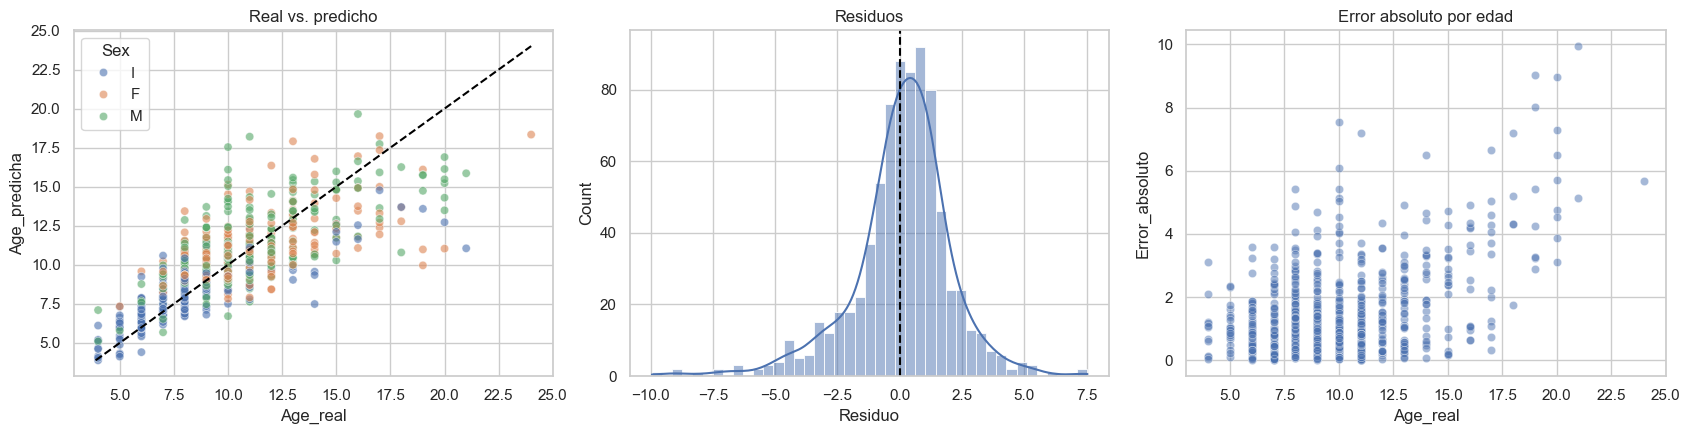

,Sex,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age_real,Age_predicha,Residuo,Error_absoluto,Rango_edad
3297,I,1.325,1.0375,0.3625,26.761928,10.900383,5.244657,7.512618,21,11.054974,-9.945026,9.945026,18+
682,F,1.450,1.1500,0.3750,28.221927,12.161936,6.010094,7.370870,19,9.965166,-9.034834,9.034834,18+
2819,F,1.575,1.2500,0.4250,37.237068,15.861545,7.569317,11.339800,20,11.036532,-8.963468,8.963468,18+
426,F,1.700,1.3750,0.4375,50.972401,23.104843,11.127179,12.899022,19,10.985523,-8.014477,8.014477,18+
3610,M,1.275,1.0000,0.3500,18.469699,6.959802,4.720192,5.244657,10,17.537671,7.537671,7.537671,8–12
1108,I,1.325,1.0500,0.4625,21.318824,8.476501,4.422522,5.811648,20,12.723864,-7.276136,7.276136,18+
225,M,1.600,1.2625,0.4125,40.922503,17.420768,8.604073,11.056305,18,10.792190,-7.207810,7.207810,18+
1043,M,1.675,1.3125,0.5000,49.342305,17.590865,8.419802,18.625622,11,18.202377,7.202377,7.202377,8–12
116,NaN,1.250,0.9625,0.2625,14.118051,5.088735,3.104270,4.819415,17,10.344297,-6.655703,6.655703,13–17
1408,M,1.575,1.2875,0.4125,38.328524,13.834556,9.893975,12.757275,20,13.488600,-6.511400,6.511400,18+


In [ ]:
comparison = pd.DataFrame([
    {'Conjunto': 'Entrenamiento', **regression_metrics(y_dev, train_pred)},
    {'Conjunto': 'Validación cruzada', 'MAE': winner_cv['MAE_CV'], 'RMSE': winner_cv['RMSE_CV'], 'R2': winner_cv['R2_CV']},
    {'Conjunto': 'Prueba', **regression_metrics(y_test, test_pred)},
]).set_index('Conjunto')
display(comparison[['MAE', 'RMSE', 'R2']].style.format('{:.3f}'))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.scatterplot(data=evaluation, x='Age_real', y='Age_predicha', hue='Sex', alpha=.6, ax=axes[0])
limit = [evaluation[['Age_real','Age_predicha']].min().min(), evaluation[['Age_real','Age_predicha']].max().max()]
axes[0].plot(limit, limit, '--', color='black'); axes[0].set_title('Real vs. predicho')
sns.histplot(data=evaluation, x='Residuo', kde=True, ax=axes[1]); axes[1].axvline(0, ls='--', color='black'); axes[1].set_title('Residuos')
sns.scatterplot(data=evaluation, x='Age_real', y='Error_absoluto', alpha=.5, ax=axes[2]); axes[2].set_title('Error absoluto por edad')
plt.tight_layout(); plt.show()
display(evaluation.nlargest(10, 'Error_absoluto'))

## 6. Interpretación mediante importancia por permutación

,Característica,Importancia_MAE,Desviación
7,Shell Weight,0.536464,0.041737
11,Shucked / Weight,0.422261,0.037703
3,Height,0.071854,0.008294
0,Sex,0.070147,0.007910
10,Shell / Weight,0.043314,0.008060
4,Weight,0.020097,0.007223
2,Diameter,0.018354,0.003994
12,Viscera / Weight,0.018290,0.009544
5,Shucked Weight,0.013754,0.003425
6,Viscera Weight,0.012803,0.004421


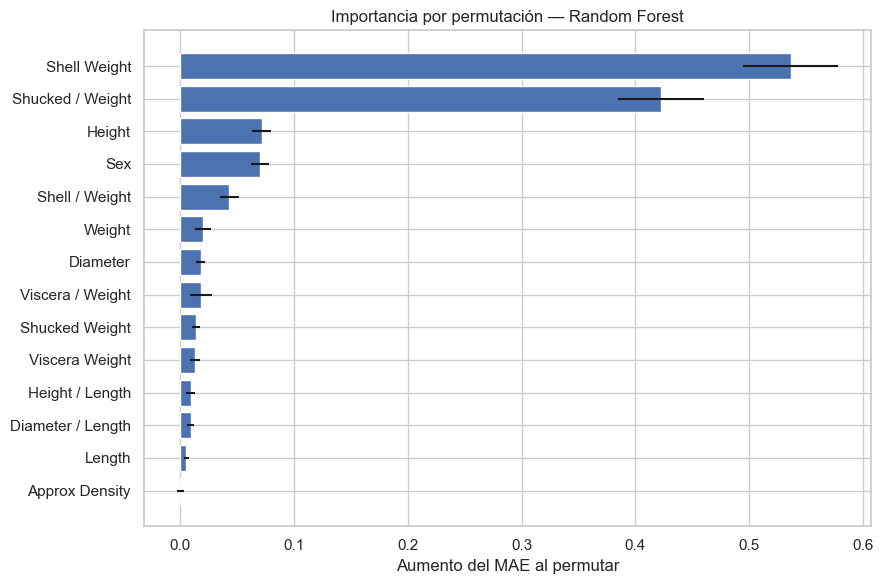

In [20]:
permutation = permutation_importance(
    winner, X_test, y_test, scoring='neg_mean_absolute_error', n_repeats=15, random_state=SEED, n_jobs=N_JOBS
)
importance = (pd.DataFrame({'Característica': X_test.columns, 'Importancia_MAE': permutation.importances_mean, 'Desviación': permutation.importances_std})
              .sort_values('Importancia_MAE', ascending=False))
display(importance)
plt.figure(figsize=(9, 6))
plot_data = importance.sort_values('Importancia_MAE')
plt.barh(plot_data['Característica'], plot_data['Importancia_MAE'], xerr=plot_data['Desviación'])
plt.xlabel('Aumento del MAE al permutar'); plt.title(f'Importancia por permutación — {winner_name}')
plt.tight_layout(); plt.show()

### SHAP (opcional)

SHAP puede aportar explicaciones locales, pero no se instala ni ejecuta por defecto para mantener el tiempo y las dependencias controlados. Si se necesita, instale `shap` y aplíquelo sobre una muestra transformada, verificando primero la compatibilidad con el estimador ganador.

## 7. Persistencia, recarga y ejemplo de uso

In [22]:
MODEL_PATH = Path('crabs_age_best_model.joblib')
RESULTS_PATH = Path('crabs_model_comparison.csv')

all_results = pd.concat([benchmark.assign(Fase='Benchmark'), tuning.assign(Fase='Ajuste')], ignore_index=True)
all_results.to_csv(RESULTS_PATH, index=False)
joblib.dump({'pipeline': winner, 'raw_features': RAW_FEATURES, 'winner_name': winner_name,
             'best_params': winner_search.best_params_, 'seed': SEED}, MODEL_PATH)
loaded_bundle = joblib.load(MODEL_PATH)
reloaded_pred = loaded_bundle['pipeline'].predict(X_test)
np.testing.assert_allclose(test_pred, reloaded_pred, rtol=0, atol=1e-12)
print('Artefactos guardados:', MODEL_PATH, RESULTS_PATH)
print('La recarga reproduce exactamente las predicciones.')

Artefactos guardados: crabs_age_best_model.joblib crabs_model_comparison.csv
La recarga reproduce exactamente las predicciones.


In [23]:
def predict_crab_age(raw_record, bundle=loaded_bundle):
    frame = pd.DataFrame([raw_record])
    missing = sorted(set(bundle['raw_features']) - set(frame.columns))
    extra = sorted(set(frame.columns) - set(bundle['raw_features']))
    if missing or extra:
        raise ValueError(f'Columnas faltantes={missing}; columnas inesperadas={extra}')
    engineered = add_physical_features(frame[bundle['raw_features']])
    prediction = float(bundle['pipeline'].predict(engineered)[0])
    return {'edad_estimada_meses': prediction, 'edad_redondeada_meses': int(np.rint(prediction))}

example_crab = {
    'Sex': 'M', 'Length': 1.45, 'Diameter': 1.12, 'Height': 0.40, 'Weight': 25.0,
    'Shucked Weight': 11.0, 'Viscera Weight': 5.5, 'Shell Weight': 7.5,
}
predict_crab_age(example_crab)

{'edad_estimada_meses': 10.144295743702541, 'edad_redondeada_meses': 10}

In [25]:
example_crabs = [
    {
        'Sex': 'M',
        'Length': 1.45,
        'Diameter': 1.12,
        'Height': 0.40,
        'Weight': 25.0,
        'Shucked Weight': 11.0,
        'Viscera Weight': 5.5,
        'Shell Weight': 7.5,
    },
    {
        'Sex': 'F',
        'Length': 1.30,
        'Diameter': 1.00,
        'Height': 0.35,
        'Weight': 20.0,
        'Shucked Weight': 8.5,
        'Viscera Weight': 4.2,
        'Shell Weight': 6.0,
    },
    {
        'Sex': 'I',
        'Length': 0.85,
        'Diameter': 0.65,
        'Height': 0.20,
        'Weight': 5.5,
        'Shucked Weight': 2.3,
        'Viscera Weight': 1.1,
        'Shell Weight': 1.7,
    },
    {
        'Sex': 'M',
        'Length': 1.60,
        'Diameter': 1.28,
        'Height': 0.45,
        'Weight': 40.0,
        'Shucked Weight': 17.0,
        'Viscera Weight': 8.0,
        'Shell Weight': 12.0,
    },
    {
        'Sex': 'F',
        'Length': 1.55,
        'Diameter': 1.22,
        'Height': 0.42,
        'Weight': 35.0,
        'Shucked Weight': 14.5,
        'Viscera Weight': 7.0,
        'Shell Weight': 10.5,
    },
    {
        'Sex': 'I',
        'Length': 1.00,
        'Diameter': 0.75,
        'Height': 0.25,
        'Weight': 8.0,
        'Shucked Weight': 3.3,
        'Viscera Weight': 1.6,
        'Shell Weight': 2.5,
    },
    {
        'Sex': 'M',
        'Length': 1.20,
        'Diameter': 0.92,
        'Height': 0.30,
        'Weight': 14.0,
        'Shucked Weight': 5.8,
        'Viscera Weight': 2.8,
        'Shell Weight': 4.3,
    },
    {
        'Sex': 'F',
        'Length': 1.70,
        'Diameter': 1.38,
        'Height': 0.50,
        'Weight': 51.0,
        'Shucked Weight': 22.0,
        'Viscera Weight': 10.5,
        'Shell Weight': 15.0,
    },
    {
        'Sex': 'I',
        'Length': 0.65,
        'Diameter': 0.48,
        'Height': 0.15,
        'Weight': 2.5,
        'Shucked Weight': 1.0,
        'Viscera Weight': 0.5,
        'Shell Weight': 0.8,
    },
    {
        # None permite probar la imputación del sexo faltante.
        'Sex': None,
        'Length': 1.35,
        'Diameter': 1.05,
        'Height': 0.38,
        'Weight': 23.0,
        'Shucked Weight': 9.5,
        'Viscera Weight': 4.8,
        'Shell Weight': 7.0,
    },
]

for i, crab in enumerate(example_crabs, start=1):
    prediction = predict_crab_age(crab)
    print(f'Cangrejo {i}: {prediction}')

Cangrejo 1: {'edad_estimada_meses': 10.144295743702541, 'edad_redondeada_meses': 10}
Cangrejo 2: {'edad_estimada_meses': 10.420861910504463, 'edad_redondeada_meses': 10}
Cangrejo 3: {'edad_estimada_meses': 6.785507507181438, 'edad_redondeada_meses': 7}
Cangrejo 4: {'edad_estimada_meses': 11.109356680207, 'edad_redondeada_meses': 11}
Cangrejo 5: {'edad_estimada_meses': 11.041403825802542, 'edad_redondeada_meses': 11}
Cangrejo 6: {'edad_estimada_meses': 7.3456788391581895, 'edad_redondeada_meses': 7}
Cangrejo 7: {'edad_estimada_meses': 9.286860154835987, 'edad_redondeada_meses': 9}
Cangrejo 8: {'edad_estimada_meses': 11.772969888504791, 'edad_redondeada_meses': 12}
Cangrejo 9: {'edad_estimada_meses': 5.814148305409059, 'edad_redondeada_meses': 6}
Cangrejo 10: {'edad_estimada_meses': 10.419744641758538, 'edad_redondeada_meses': 10}


In [26]:
versions = {
    'Python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__, 'catboost': __import__('catboost').__version__,
    'xgboost': __import__('xgboost').__version__, 'lightgbm': __import__('lightgbm').__version__,
}
display(pd.Series(versions, name='Versión').to_frame())

,Versión
Python,3.13.1
numpy,2.2.0
pandas,2.2.3
scikit-learn,1.9.0
catboost,1.2.10
xgboost,3.4.1
lightgbm,4.7.0


## 8. Conclusión automática

La siguiente celda genera un resumen basado en los resultados reales, evitando conclusiones escritas antes de ejecutar el experimento.

In [27]:
dummy_mae = benchmark.set_index('Modelo').loc['Dummy mediana', 'MAE_CV']
linear_mae = benchmark.set_index('Modelo').loc['Regresión lineal', 'MAE_CV']
sex_metrics = metrics_by_group(evaluation, 'Sex')['MAE']
age_metrics = metrics_by_group(evaluation, 'Rango_edad')['MAE']
print(f'''CONCLUSIÓN
Modelo ganador: {winner_name}
MAE CV: {winner_cv['MAE_CV']:.3f} ± {winner_cv['MAE_std']:.3f} meses
MAE prueba: {final_metrics.loc[winner_name, 'MAE']:.3f} meses
Mejora frente a Dummy: {(dummy_mae-final_metrics.loc[winner_name, 'MAE']):.3f} meses
Mejora frente a regresión lineal CV: {(linear_mae-winner_cv['MAE_CV']):.3f} meses
Mejor grupo por sexo: {sex_metrics.idxmin()} (MAE={sex_metrics.min():.3f})
Peor grupo por sexo: {sex_metrics.idxmax()} (MAE={sex_metrics.max():.3f})
Mejor rango de edad: {age_metrics.idxmin()} (MAE={age_metrics.min():.3f})
Peor rango de edad: {age_metrics.idxmax()} (MAE={age_metrics.max():.3f})

Limitaciones: las edades altas son escasas, las mediciones pueden contener valores físicos sospechosos y el conjunto proviene de una sola fuente. Antes de producción se requiere validación externa, controles de entrada, monitoreo de deriva y una política para predicciones fuera del rango observado.
''')

CONCLUSIÓN
Modelo ganador: Random Forest
MAE CV: 1.511 ± 0.024 meses
MAE prueba: 1.422 meses
Mejora frente a Dummy: 0.975 meses
Mejora frente a regresión lineal CV: 0.125 meses
Mejor grupo por sexo: I (MAE=1.095)
Peor grupo por sexo: M (MAE=1.562)
Mejor rango de edad: 1–7 (MAE=0.996)
Peor rango de edad: 18+ (MAE=5.408)

Limitaciones: las edades altas son escasas, las mediciones pueden contener valores físicos sospechosos y el conjunto proviene de una sola fuente. Antes de producción se requiere validación externa, controles de entrada, monitoreo de deriva y una política para predicciones fuera del rango observado.

